<a href="https://colab.research.google.com/github/Aswathyak26/Aswathyak/blob/main/Loan_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [156]:
train = pd.read_csv(r'/content/train_ctrUa4K.csv')
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [157]:
test = pd.read_csv(r'/content/test_lAUu6dG.csv')
test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [158]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [159]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [160]:
train= train.drop(columns=['Loan_ID'])
test = test.drop(columns=['Loan_ID'])

In [161]:
print("\nMissing Values :")
train.isnull().sum()


Missing Values :


,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [162]:
test.isnull().sum()

,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6
Credit_History,29


In [163]:
# Missing numerical columns
missing_num_cols_train = [col for col in train.select_dtypes(include=['number']).columns if train[col].isnull().sum() > 0]

print("Missing Numerical Columns:\n", missing_num_cols)

Missing Numerical Columns:
 ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [164]:
# Missing numerical columns
missing_num_cols_test = [col for col in test.select_dtypes(include=['number']).columns if test[col].isnull().sum() > 0]

print("Missing Numerical Columns:\n", missing_num_cols)

Missing Numerical Columns:
 ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [165]:
# 1.  Missing Continuous numerical features - Median
median_cols = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for i in median_cols:
    train[i] = train[i].fillna(train[i].median())

In [166]:
# 1.  Missing Continuous numerical features - Median
median_cols = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for i in median_cols:
    test[i] = test[i].fillna(test[i].median())

In [167]:
mode_cols = ['Gender', 'Dependents', 'Self_Employed','Married']
for i in mode_cols:
 train[i] = train[i].fillna(train[i].mode()[0])

In [168]:
mode_cols = ['Gender', 'Dependents', 'Self_Employed']
for i in mode_cols:
  test[i] = test[i].fillna(test[i].mode()[0])

In [169]:
train.isna().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [170]:
test.isna().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [171]:
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = train.select_dtypes(include=['object']).columns

print('Numerical Columns:\n', numerical_cols)
print('\nCategorical Columns:\n', categorical_cols)

Numerical Columns:
 Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

Categorical Columns:
 Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')


In [172]:
numerical_cols = test.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = test.select_dtypes(include=['object']).columns

print('Numerical Columns:\n', numerical_cols)
print('\nCategorical Columns:\n', categorical_cols)

Numerical Columns:
 Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

Categorical Columns:
 Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object')


In [173]:
train['Loan_Status'].unique()

array(['Y', 'N'], dtype=object)

In [174]:
train['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [175]:
train['Married'].unique()

array(['No', 'Yes'], dtype=object)

In [176]:
train['Dependents'].unique()

array(['0', '1', '2', '3+'], dtype=object)

In [177]:
train['Education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [178]:
train['Self_Employed'].unique()

array(['No', 'Yes'], dtype=object)

In [179]:
train['Property_Area'].unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [180]:
condition_mapping = {'Male': 0,'Female':1}
train['Gender'] = train['Gender'].map(condition_mapping)

In [181]:
condition_mapping = {'Male': 0,'Female':1}
test['Gender'] = test['Gender'].map(condition_mapping)

In [182]:
condition_mapping = {'Yes': 1, 'No': 0}
train['Married'] = train['Married'].map(condition_mapping)

In [183]:
condition_mapping = {'Yes': 1, 'No': 0}
test['Married'] = test['Married'].map(condition_mapping)

In [184]:
condition_mapping = {'Graduate': 1, 'Not Graduate': 0}
train['Education'] = train['Education'].map(condition_mapping)

In [185]:
condition_mapping = {'Graduate': 1, 'Not Graduate': 0}
test['Education'] = test['Education'].map(condition_mapping)

In [186]:
condition_mapping = {'Yes': 1, 'No': 0}
train['Self_Employed'] = train['Self_Employed'].map(condition_mapping)


In [187]:
condition_mapping = {'Yes': 1, 'No': 0}
test['Self_Employed'] = test['Self_Employed'].map(condition_mapping)

In [188]:
condition_mapping = {'Y': 1, 'N': 0}
train['Loan_Status'] = train['Loan_Status'].map(condition_mapping)


In [189]:
#Nominal category -one hot Encoding
# no order among categories, therefore One-Hot Encoding is more suitable than label mapping.
train = pd.get_dummies(train, columns=['Property_Area'], dtype='int')

In [190]:
#Nominal category -one hot Encoding
# no order among categories, therefore One-Hot Encoding is more suitable than label mapping.
test = pd.get_dummies(test, columns=['Property_Area'], dtype='int')

In [191]:
condition_mapping = {'0': 0,'1': 1,'2': 2,'3+': 3}
train['Dependents'] = train['Dependents'].map(condition_mapping)


In [192]:
condition_mapping = {'0': 0,'1': 1,'2': 2,'3+': 3}
test['Dependents'] = test['Dependents'].map(condition_mapping)

In [195]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,0,0,1
1,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0
2,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,0,0,1
3,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,0,0,1
4,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,0,0,1


In [196]:
x = train.drop(['Loan_Status'], axis=1)
y = train['Loan_Status'] #Target

In [197]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
x = std_scaler.fit_transform(x)
x = pd.DataFrame(x)

In [198]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,random_state = 42)

In [199]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score,recall_score, f1_score

In [207]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

In [208]:
def evaluate_model(model, model_name):

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    #Using one specific train-test split, my model correctly classified _% of the test samples
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred) #Higher recall means fewer cancer cases are missed.
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
     # Stratified K-Fold Cross Validation
    skf = StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
    cv_results = {}
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    for metric in metrics:
        #The CV numbers provide evidence if the model's performance is reliable and not dependent on a single split
        cv_scores = cross_val_score(model,x,y,cv=skf,scoring= metric)
        #if I repeatedly train and test this model on different portions of the dataset
        cv_results[f'CV {metric.title()} Mean'] = round(np.mean(cv_scores), 6)
        #This measures how much the fold accuracies vary.
        cv_results[f'CV {metric.title()} Std'] = round(np.std(cv_scores), 6)
    results_df = pd.DataFrame({'Model': [model_name],'Accuracy': [round(accuracy, 6)],
    'Precision': [round(precision, 6)],'Recall': [round(recall, 6)],
    'F1 Score': [round(f1, 6)],'Confusion Matrix': [cm.tolist()],**cv_results})
    return results_df

In [209]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=100)
evaluate_model(lr, "Logistic Regression")

,Model,Accuracy,Precision,Recall,F1 Score,Confusion Matrix,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std
0,Logistic Regression,0.788618,0.759615,0.9875,0.858696,"[[18, 25], [1, 79]]",0.809413,0.026628,0.791869,0.01979,0.981008,0.014268,0.876263,0.01629


In [210]:
from sklearn.naive_bayes import GaussianNB
nb_classifier = GaussianNB()
evaluate_model(nb_classifier,'NAIVE BAYES')

,Model,Accuracy,Precision,Recall,F1 Score,Confusion Matrix,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std
0,NAIVE BAYES,0.780488,0.757282,0.975,0.852459,"[[18, 25], [2, 78]]",0.791512,0.027282,0.789851,0.019446,0.950221,0.034439,0.862221,0.018465


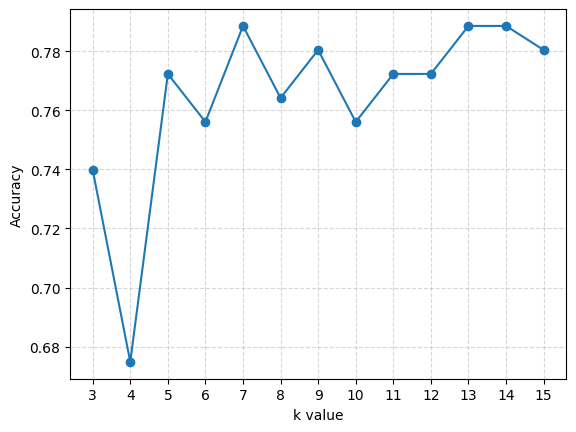

In [211]:
from sklearn.neighbors import KNeighborsClassifier
metric_k = []  #create a empty list for k accuracy values
neighbors = np.arange(3, 16)
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn = knn.fit(x_train, y_train)
    y_pred_knn = knn.predict(x_test)
    acc = accuracy_score(y_test, y_pred_knn)
    metric_k.append(acc)
plt.plot(neighbors, metric_k, 'o-')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.xticks(neighbors)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [221]:
knn= KNeighborsClassifier(n_neighbors = 7, metric = 'euclidean')  #took k = 10 beacuse it has highest accuracy
manual_knn = evaluate_model(knn,"KNN - Manual")
manual_knn

,Model,Accuracy,Precision,Recall,F1 Score,Confusion Matrix,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std
0,KNN - Manual,0.788618,0.759615,0.9875,0.858696,"[[18, 25], [1, 79]]",0.794765,0.020975,0.787272,0.017467,0.962016,0.030458,0.865532,0.014514


In [215]:
from sklearn.svm import SVC
svm_linear = evaluate_model(SVC(kernel='linear'), "SVM - Linear")
svm_rbf = evaluate_model(SVC(kernel='rbf'),"SVM - RBF")
svm_poly = evaluate_model( SVC(kernel='poly'),"SVM - Polynomial")
pd.concat([svm_linear, svm_rbf, svm_poly],ignore_index=True)

,Model,Accuracy,Precision,Recall,F1 Score,Confusion Matrix,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std
0,SVM - Linear,0.788618,0.759615,0.9875,0.858696,"[[18, 25], [1, 79]]",0.809439,0.022008,0.790816,0.017876,0.983389,0.010876,0.876545,0.013051
1,SVM - RBF,0.796748,0.761905,1.0000,0.864865,"[[18, 25], [0, 80]]",0.809439,0.019412,0.790856,0.016854,0.983389,0.015220,0.876510,0.011646
2,SVM - Polynomial,0.780488,0.757282,0.9750,0.852459,"[[18, 25], [2, 78]]",0.798017,0.032226,0.792701,0.023238,0.957364,0.031474,0.866939,0.020694


In [216]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42) #By default Gini
manual_dt = evaluate_model(dt,"DECISION TREE - Manual")

In [217]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt'],
    'class_weight': [None, 'balanced']
}
# Metrics to evaluate model
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']

# Storage
results = {}  # stores best score + best parameters
models = {} # stores trained best model for each metric

# Loop through metrics
from sklearn.model_selection import GridSearchCV
classifier = DecisionTreeClassifier(random_state=42)
for metric in scoring_metrics:
    grid_search = GridSearchCV( estimator=classifier,param_grid=param_grid,cv=5,scoring=metric,verbose=1)
    grid_search.fit(x_train, y_train)
    # best score for this metric and best combination of hyperparameters
    results[metric] = {"best_score": grid_search.best_score_,"best_params": grid_search.best_params_ }
    models[metric] = grid_search.best_estimator_ # store best trained model for this metric

# Convert dict to DataFrame for easy comparison
results_df = pd.DataFrame([
    {
        "metric": metric, # metric name (accuracy/precision/recall/f1)
        "best_score": results[metric]["best_score"],# best validation score
        "best_params": results[metric]["best_params"]  # best hyperparameters
    }
    for metric in results
])
pd.set_option('display.width', 1000) # avoid line wrapping
pd.set_option('display.max_colwidth', None) # show full dictionary

results_df["best_params"] = results_df["best_params"].astype(str) # convert dict to string for clean printing
print(results_df)

Fitting 5 folds for each of 504 candidates, totalling 2520 fits
Fitting 5 folds for each of 504 candidates, totalling 2520 fits
Fitting 5 folds for each of 504 candidates, totalling 2520 fits
Fitting 5 folds for each of 504 candidates, totalling 2520 fits
      metric  best_score                                                                                                                                 best_params
0   accuracy    0.814595      {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 2, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
1  precision    0.849421  {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10}
2     recall    0.985379       {'class_weight': None, 'criterion': 'entropy', 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2}
3         f1    0.880864      {'class_weight': 'balanced', 'criterion': 'gini', 'max

In [218]:
#Best model
best_metric ='accuracy'
best_dt = models[best_metric]
grid_dt= evaluate_model(best_dt,"DECISION TREE - Grid Search ")

pd.concat([manual_dt,grid_dt],ignore_index=True)

,Model,Accuracy,Precision,Recall,F1 Score,Confusion Matrix,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std
0,DECISION TREE - Manual,0.674797,0.738095,0.7750,0.756098,"[[21, 22], [18, 62]]",0.711687,0.048509,0.793006,0.042862,0.788815,0.064928,0.788979,0.039112
1,DECISION TREE - Grid Search,0.788618,0.759615,0.9875,0.858696,"[[18, 25], [1, 79]]",0.809439,0.022008,0.790816,0.017876,0.983389,0.010876,0.876545,0.013051


In [224]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
manual_rf  = evaluate_model(rf,"RANDOM FOREST - Manual")
manual_rf

,Model,Accuracy,Precision,Recall,F1 Score,Confusion Matrix,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std
0,RANDOM FOREST - Manual,0.780488,0.757282,0.975,0.852459,"[[18, 25], [2, 78]]",0.768614,0.043039,0.787171,0.025494,0.909801,0.056286,0.843279,0.032345


In [225]:
def e_model(model):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return accuracy, precision, recall, f1

In [226]:
results = pd.DataFrame(columns=['Accuracy','Precision','Recall','F1'])
results.loc['Logistic Regression'] = e_model(LogisticRegression(max_iter=100))
results.loc['Naive Bayes'] = e_model(GaussianNB())
results.loc['KNN'] = e_model(KNeighborsClassifier(n_neighbors = 10, metric = 'euclidean'))
results.loc['SVM'] = e_model(SVC(kernel='rbf'))
results.loc['Decision Tree'] = e_model(DecisionTreeClassifier(random_state=42))
results.loc['Random Forest'] = e_model(RandomForestClassifier(random_state=42))
print(results)

                     Accuracy  Precision  Recall        F1
Logistic Regression  0.788618   0.759615  0.9875  0.858696
Naive Bayes          0.780488   0.757282  0.9750  0.852459
KNN                  0.756098   0.740385  0.9625  0.836957
SVM                  0.796748   0.761905  1.0000  0.864865
Decision Tree        0.674797   0.738095  0.7750  0.756098
Random Forest        0.780488   0.757282  0.9750  0.852459


In [231]:
test_scaled = std_scaler.transform(test)

In [232]:
from sklearn.svm import SVC

final_svm = SVC(kernel='rbf')

final_svm.fit(x, y)

SVC()

In [233]:
from sklearn.svm import SVC

final_svm = SVC(kernel='rbf')

final_svm.fit(x, y)

SVC()

In [235]:
predictions = final_svm.predict(test_scaled)

print(predictions[:10])
predictions = ['Y' if p == 1 else 'N' for p in predictions]

[1 1 1 1 1 1 1 0 1 1]


In [236]:
test_original = pd.read_csv('/content/test_lAUu6dG.csv')

In [237]:
submission = pd.DataFrame({
    'Loan_ID': test_original['Loan_ID'],
    'Loan_Status': predictions
})

submission.head()

,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y


In [238]:
submission.to_csv('submission.csv', index=False)

In [239]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>